In [1]:
data = 'covid_data.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
df = pd.read_csv(data)

In [ ]:
# Task 1

In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
cols = ['new_cases', 'date', 'location']
df[cols].isnull().sum()

new_cases    19276
date             0
location         0
dtype: int64

In [6]:
df['new_cases'] = df['new_cases'].fillna(0)

In [7]:
df['high_cases'] = (df['new_cases'] > 1000).astype(int)

In [8]:
df = df[['continent', 'iso_code', 'total_cases', 'total_deaths', 'total_vaccinations', 'population', 'new_cases', 'high_cases']]
df = df.dropna()

In [9]:
df

,continent,iso_code,total_cases,total_deaths,total_vaccinations,population,new_cases,high_cases
414,Asia,AFG,55604.0,2432.0,0.0,41128772,0.0,0
420,Asia,AFG,55714.0,2443.0,8200.0,41128772,110.0,0
436,Asia,AFG,55985.0,2457.0,54000.0,41128772,0.0,0
458,Asia,AFG,56676.0,2497.0,120000.0,41128772,0.0,0
473,Asia,AFG,57793.0,2539.0,240000.0,41128772,0.0,0
...,...,...,...,...,...,...,...,...
428761,Africa,ZWE,257340.0,5599.0,12212594.0,16320539,0.0,0
428762,Africa,ZWE,257517.0,5602.0,12214870.0,16320539,177.0,0
428763,Africa,ZWE,257517.0,5602.0,12216848.0,16320539,0.0,0
428765,Africa,ZWE,257517.0,5602.0,12219760.0,16320539,0.0,0


In [10]:
X = df.drop(['high_cases', 'new_cases'], axis=1)
y = df['high_cases']

In [11]:
# Task 2

In [12]:
X = pd.get_dummies(X, columns=['continent'], drop_first=True)

In [13]:
le = LabelEncoder()
X['iso_code'] = le.fit_transform(X['iso_code'])

In [14]:
scaler = StandardScaler()
num_columns = ['total_cases', 'total_deaths', 'total_vaccinations', 'population']
X[num_columns] = scaler.fit_transform(X[num_columns])

In [ ]:
# Task 3

In [15]:
from imblearn.over_sampling import SMOTE

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [17]:
smote = SMOTE(random_state=45)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [19]:
models = {
    "LR": LogisticRegression(max_iter=1000),
    "DT": DecisionTreeClassifier(),
    "RF": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

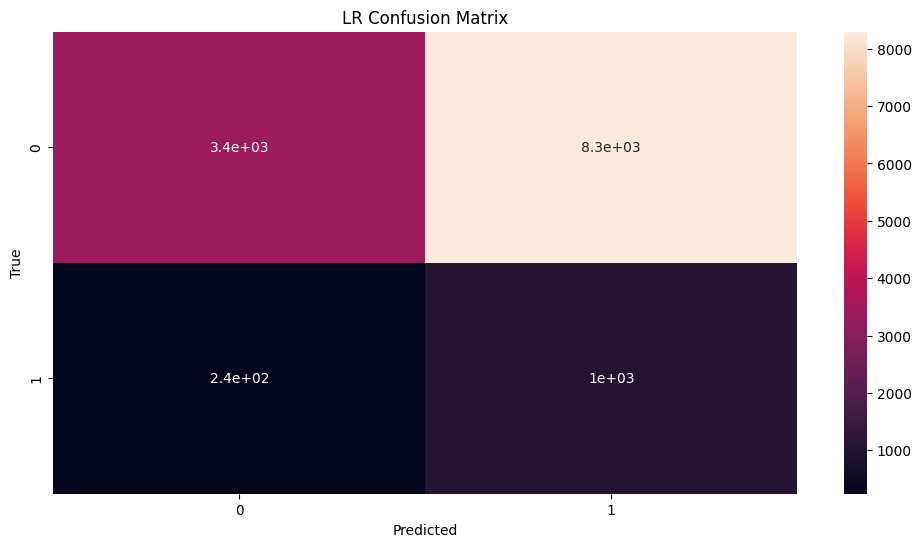

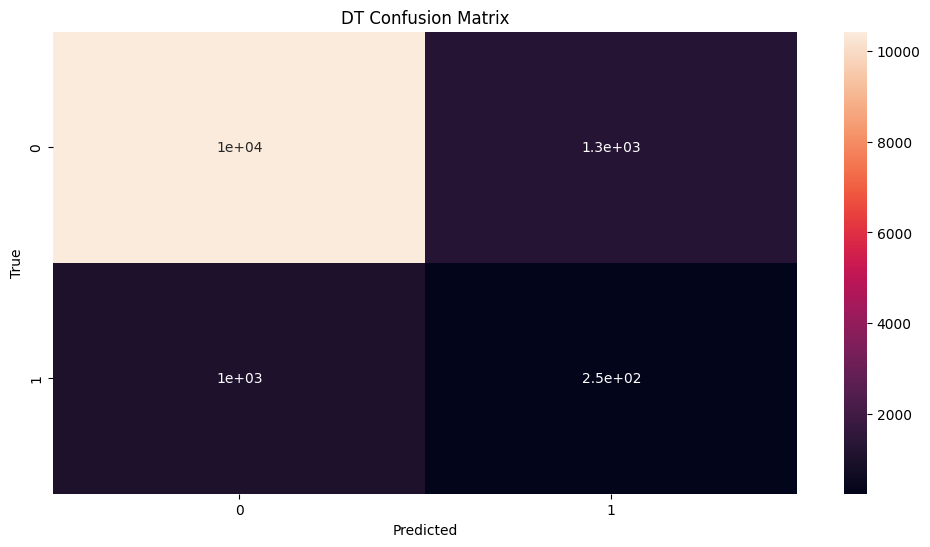

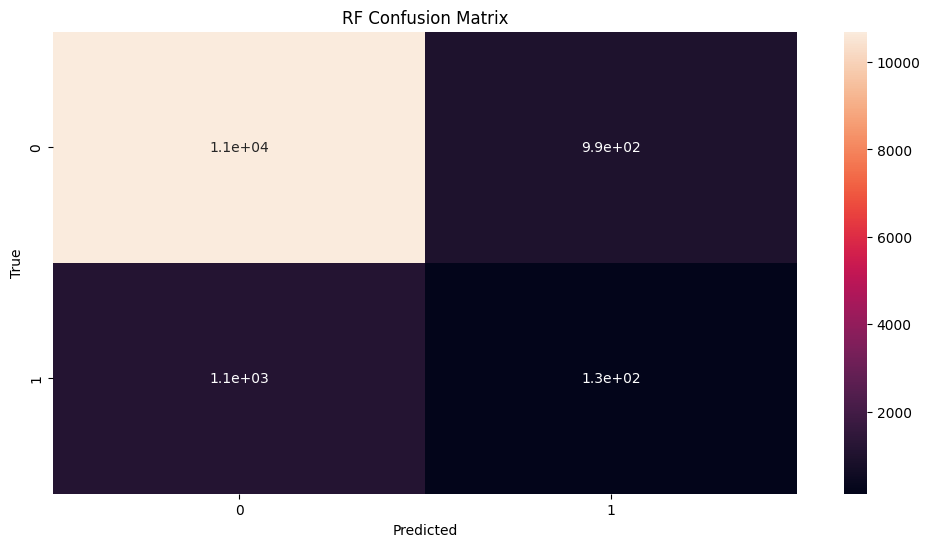

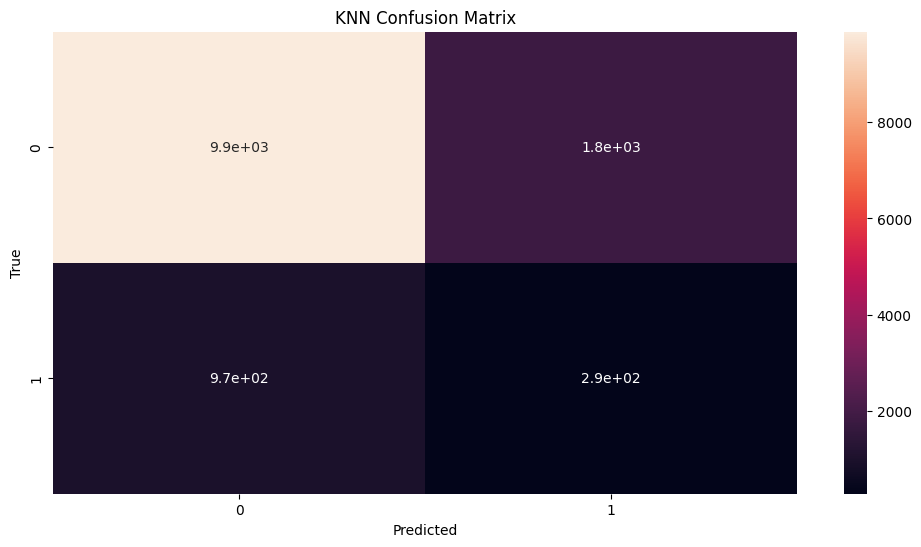

In [20]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 6))
    sns.heatmap(cm, annot=True)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [21]:
pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1
LR,0.340261,0.109370,0.808730,0.192682
DT,0.824229,0.164130,0.196825,0.178997
RF,0.835896,0.113596,0.100794,0.106812
KNN,0.785058,0.136581,0.226984,0.170543


In [22]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    FN = cm[1][0]
    print(f"{name} FN: {FN}")

LR FN: 241
DT FN: 1012
RF FN: 1133
KNN FN: 974


In [23]:
from sklearn.model_selection import cross_val_score

In [ ]:
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')

    cv_results[name] = {
        "Mean F1": scores.mean(),
        "Std": scores.std()
    }

In [ ]:
pd.DataFrame(cv_results).T

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
param_frid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
}

In [ ]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_frid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)

In [ ]:
best_rf = grid.best_params_
y_pred = best_rf.predict(X_test)

In [28]:
print("With best params:", f1_score(y_test, y_pred))

With best params: 0.17054263565891473


In [31]:
from sklearn.ensemble import GradientBoostingClassifier

In [36]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

In [37]:
gb_accuracy = accuracy_score(y_test, y_pred)
gb_f1 = f1_score(y_test, y_pred)

In [38]:
print(f"GB Accuracy: {gb_accuracy:.4f}")
print(f"GB F1: {gb_f1:.4f}")

GB Accuracy: 0.4742
GB F1: 0.2325


In [ ]:
# Task 6

In [39]:
from sklearn.feature_selection import SelectKBest, f_classif

In [40]:
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

In [41]:
selected_features

Index(['iso_code', 'total_cases', 'total_deaths', 'total_vaccinations',
       'population', 'continent_Asia', 'continent_Europe',
       'continent_North America', 'continent_Oceania',
       'continent_South America'],
      dtype='object')

In [42]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=45
    )

In [43]:
model = RandomForestClassifier()
model.fit(X_train_new, y_train_new)

y_pred = model.predict(X_test_new)

In [44]:
print(f"Accuracy: {accuracy_score(y_test_new, y_pred)}")

Accuracy: 0.854825001931546


In [ ]:
# Task 4

In [45]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures

In [46]:
df

,continent,iso_code,total_cases,total_deaths,total_vaccinations,population,new_cases,high_cases
414,Asia,AFG,55604.0,2432.0,0.0,41128772,0.0,0
420,Asia,AFG,55714.0,2443.0,8200.0,41128772,110.0,0
436,Asia,AFG,55985.0,2457.0,54000.0,41128772,0.0,0
458,Asia,AFG,56676.0,2497.0,120000.0,41128772,0.0,0
473,Asia,AFG,57793.0,2539.0,240000.0,41128772,0.0,0
...,...,...,...,...,...,...,...,...
428761,Africa,ZWE,257340.0,5599.0,12212594.0,16320539,0.0,0
428762,Africa,ZWE,257517.0,5602.0,12214870.0,16320539,177.0,0
428763,Africa,ZWE,257517.0,5602.0,12216848.0,16320539,0.0,0
428765,Africa,ZWE,257517.0,5602.0,12219760.0,16320539,0.0,0


In [47]:
X_reg = df.drop(['new_cases', 'high_cases'], axis=1)
y = df['new_cases']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [49]:
models = {
    "LR": LinearRegression(),
    "Lasso": Lasso(),
    "Ridle": Ridge(),
}

results = {}

In [50]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "MSE": mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    }

In [51]:
pd.DataFrame(results).T

,MSE,R2,RMSE,MAE
LR,9.128279e+09,0.009945,95542.026489,19307.637318
Lasso,9.128131e+09,0.009961,95541.250284,19303.437654
Ridle,9.128197e+09,0.009954,95541.597674,19305.653665


In [52]:
le = LabelEncoder()
X_reg['iso_code'] = le.fit_transform(X_reg['iso_code'])
X_reg['continent'] = le.fit_transform(X_reg['continent'])

In [53]:
lr = LinearRegression()

In [54]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_reg)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

results['Polynomial'] = {
    "MSE": mean_squared_error(y_test, y_pred),
    "R2": r2_score(y_test, y_pred),
    "RMSE": root_mean_squared_error(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred)
}

In [55]:
pd.DataFrame(results).T

,MSE,R2,RMSE,MAE
LR,9.128279e+09,0.009945,95542.026489,19307.637318
Lasso,9.128131e+09,0.009961,95541.250284,19303.437654
Ridle,9.128197e+09,0.009954,95541.597674,19305.653665
Polynomial,1.263816e+11,0.060123,355501.884741,18850.346211
